In [1]:
import os

os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd
import scripts.phot_toolkits as phot_tk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import knuth_bin_width
from pathlib import Path
import csv
%load_ext autoreload
%autoreload 2



In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


In [5]:
JWST_files              = phot_tk.Pipeline_level_2_data(working_directory = "/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_2/mastDownload/JWST")
JWST_files.run_pipeline_all(filt = 'F115W', overwrite_always_run=False, Number_of_systems=5)

Initialized data in ['F187N', 'F115W', 'F444W']
----Initializing Pipeline for F115W---------
----Results stored in mosaic_F115W_test-----
----We have a total of 5# to run----------


(2) Aligning with gaia catalog: 100%|██████████| 5/5 [00:00<00:00, 881.01it/s]

(3) Creating association file
(4) Running Image3Pipeline JWST with tweakreg DISABLED
(5) Plotting resutling mosaic


KeyboardInterrupt: 

In [3]:
# gaia_cat_path =  str(Path(JWST_files.wdir).parent.parent) + '/ngc346_gaia_dr3_5arcmin.txt'
# gaia_cat_path_clean =  str(Path(JWST_files.wdir).parent.parent) + '/ngc346_gaia_dr3_5arcmin_clean.txt'

# names = ['source_id','ra','dec','parallax','pmra','pmdec',
#          'phot_g_mean_mag','phot_g_mean_flux_over_error',
#          'phot_bp_mean_mag','phot_bp_mean_flux_over_error',
#          'phot_rp_mean_mag','phot_rp_mean_flux_over_error',
#          'phot_g_mean_mag_error','phot_bp_mean_mag_error','phot_rp_mean_mag_error']

# df = pd.read_csv(gaia_cat_path, sep=r'\s+', comment='#', header=None,
#                  names=names, na_values=['""','"'], quoting=csv.QUOTE_NONE)
# df.to_csv(gaia_cat_path_clean, sep=' ', index=False, na_rep='NaN')

In [4]:
JWST_files.run_pipeline_single( IMAGE_INDEX         = 81,
                                detection_sigma     = 2.0,
                                overwrite_always_run= False,
                                save                = True,)


NameError: name 'JWST_files' is not defined

In [ ]:
IMAGE_INDEX = 81

RA_min, RA_max      = JWST_files.aperture_data['F115W'].RA.min(), JWST_files.aperture_data['F115W'].RA.max()
DEC_min, DEC_max    = JWST_files.aperture_data['F115W'].DEC.min(), JWST_files.aperture_data['F115W'].DEC.max()
region              = np.array([[RA_min, RA_max], [DEC_min, DEC_max] ])
print(region)
region              = np.array([[14.78257831, 14.79257831], [-72.12083538, -72.117511671] ])
print(region)


catalogue_path  = 'Photometry/NGC346_NIRCam_and_MIRI_Public_JWST_Catalogue.fits'
Catalogue       = phot_tk.Read_Catalogue(catalogue_path = catalogue_path)
Catalogue.mask_region(RA = (RA_min, RA_max ), DEC = (DEC_min, DEC_max))

specific_ra_dec = np.vstack([Catalogue.sub_cat_data['ra'], Catalogue.sub_cat_data['dec']])

JWST_files.show_detections( filters             = ['F115W'],
                            image_type          = 'bgsub',
                            IMAGE_INDEX         = IMAGE_INDEX,
                            draw_own_detections = False,
                            specific_ra_dec     = specific_ra_dec, #np.array([[], []]), #
                            marker_radius_pixel = 3,
                            save                = True,
                            save_dir            = 'Plots/show_detections',
                            region              = region)#


In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord

sky1 =  JWST_files.world_coord_sources['F115W'] 
sky2 = SkyCoord(Catalogue.sub_cat_data['ra'] * u.deg,
                Catalogue.sub_cat_data['dec'] * u.deg)

A, B, a_idx, b_idx = JWST_files.cross_match_detections(sky1=sky1, sky2=sky2, det_tol=0.5*u.arcsec)

In [ ]:
from tabulate import tabulate


table_data = zip(A[a_idx][:, 0], B[b_idx][:, 0],A[a_idx][:, 1], B[b_idx][:, 1], JWST_files.magnitudes['F115W'][a_idx], Catalogue.sub_cat_data['F115W'][b_idx])

print(tabulate(table_data, headers=['ra own','ra jeroen','dec own','dec jeroen','mag own', 'mag Jeroen'],tablefmt="grid"))


In [ ]:
catalogue_path  = 'Photometry/NGC346_NIRCam_and_MIRI_Public_JWST_Catalogue.fits'
Catalogue       = phot_tk.Read_Catalogue(catalogue_path = catalogue_path)
Catalogue.mask_region(RA = (RA_min, RA_max ), DEC = (DEC_min, DEC_max))


In [ ]:
fig = plt.figure()
gs = fig.add_gridspec(1, 1, figure=fig, wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])


filter  = 'F187N'
mask    = Catalogue.sub_cat_data[filter] < 50
samples = Catalogue.sub_cat_data[filter][mask]
N_samples = len(samples)


dx, bin_edges = knuth_bin_width(samples, return_bins=True)
hist = np.histogram(samples, bins=bin_edges)[0]
ax0.stairs(
    hist,
    edges=bin_edges, fill=False, label=f'Catalogue        - {N_samples}', lw=2, edgecolor='black'
    )


own_phot = JWST_files.magnitudes[filter]
N_own_phot = len(own_phot)
own_hist = np.histogram(own_phot, bins=bin_edges)[0]
ax0.stairs(
    own_hist,
    edges=bin_edges, fill=False, label=f'aperture_phot  - {N_own_phot}', lw=2, edgecolor='blue'
    )
    

ax0.legend()
ax0.set_xlabel("Vega Magnitude")
ax0.set_ylabel("Count")
ax0.set_ylim(0, 500)
fig.suptitle(f"Detected sources in {filter} ")
plt.show()

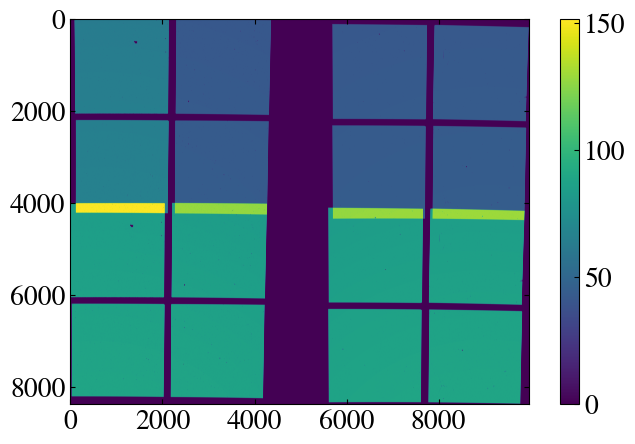

In [ ]:

from astropy.visualization import ZScaleInterval

level3_data_path    = '/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_3/'


hdu = fits.open(level3_data_path + 'mosaic_F115W_test_i2d.fits')

Image               = hdu[1].data
interval            = ZScaleInterval()
vmin, vmax          = interval.get_limits(Image)

plt.imshow(hdu['WHT'].data)
plt.colorbar()

In [24]:
def Split_Mosaic_on_WHT(mosaic_path = level3_data_path + 'mosaic_F115W_test_i2d.fits',
                        wht_threshold = 70.0):
    
    hdu = fits.open(mosaic_path) #large file! takes long   
        
    # Build masks & Apply
    wht_data = hdu['WHT'].data
    long_exposure_mask      = wht_data > wht_threshold
    short_exposure_mask     = ~long_exposure_mask   # everything <= threshold, including WHT == 0
    long_exposure_data      = []
    short_exposure_data     = []

    for fit_frame in ['SCI', 'ERR',  'WHT', 'VAR_POISSON','VAR_RNOISE', 'VAR_FLAT']: #con
        data    = hdu[fit_frame].data
        header  = hdu[fit_frame].header
        long_exposure_data.append( fits.ImageHDU(data  = np.where(long_exposure_mask, data, np.nan).astype(data.dtype),
                 header=header, name=fit_frame))
        
        short_exposure_data.append( fits.ImageHDU(data = np.where(short_exposure_mask, data, np.nan).astype(data.dtype),
                 header=header, name=fit_frame))
        
    hdu_out = fits.HDUList([fits.PrimaryHDU(header  = hdu[0].header)] + long_exposure_data)
    hdu_out.writeto( level3_data_path + 'mosaic_F115W_long_exposure.fits', overwrite=True)
    
    hdu_out = fits.HDUList([fits.PrimaryHDU(header  = hdu[0].header)] + short_exposure_data)
    hdu_out.writeto( level3_data_path + 'mosaic_F115W_short_exposure.fits', overwrite=True)

    hdu.close()
    return

Split_Mosaic_on_WHT()



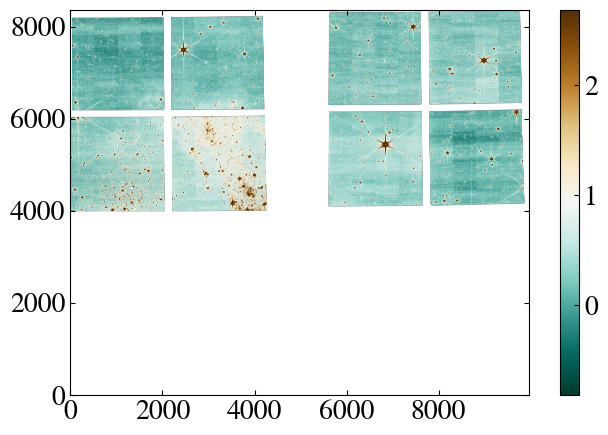

In [25]:
hdu                 = fits.open(level3_data_path + 'mosaic_F115W_long_exposure.fits')
Image               = hdu[1].data
interval            = ZScaleInterval()
vmin, vmax          = interval.get_limits(Image)

plt.imshow(hdu['SCI'].data, cmap='BrBG_r',  vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar()

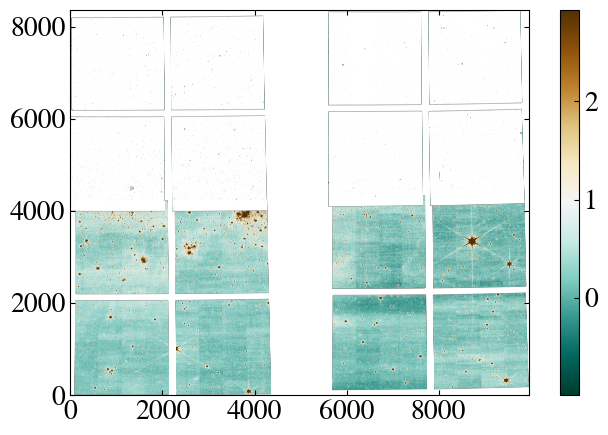

In [26]:
hdu                 = fits.open(level3_data_path + 'mosaic_F115W_short_exposure.fits')
Image               = hdu[1].data
interval            = ZScaleInterval()
vmin, vmax          = interval.get_limits(Image)

plt.imshow(hdu['SCI'].data, cmap='BrBG_r',  vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar()